In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from src.data_loader import load_processed_prices

In [2]:
prices = load_processed_prices()

prices = prices[
    ["TSLA", "SPY", "BND"]
]

prices.head()

,TSLA,SPY,BND
Date,,,
2015-01-02,14.620667,169.687851,59.205647
2015-01-05,14.006000,166.623306,59.377579
2015-01-06,14.085333,165.053909,59.549515
2015-01-07,14.063333,167.110672,59.585354
2015-01-08,14.041333,170.076096,59.492188


Daily Returns

In [3]:
returns = prices.pct_change().dropna()

returns.head()

,TSLA,SPY,BND
Date,,,
2015-01-05,-0.042041,-0.018060,0.002904
2015-01-06,0.005664,-0.009419,0.002896
2015-01-07,-0.001562,0.012461,0.000602
2015-01-08,-0.001564,0.017745,-0.001564
2015-01-09,-0.018802,-0.008014,0.001686


Define Backtesting Period

In [4]:
backtest_returns = returns.loc["2025-01-01":"2026-01-01"]

backtest_returns.head()

,TSLA,SPY,BND
Date,,,
2025-01-02,-0.060816,-0.002457,0.000417
2025-01-03,0.082156,0.012503,-0.001251
2025-01-06,0.001486,0.005761,-0.000974
2025-01-07,-0.040603,-0.011304,-0.003483
2025-01-08,0.001471,0.001461,0.001118


Strategy Portfolio

In [5]:
strategy_weights = np.array([

0.00,

0.4482,

0.5518

])

Benchmark Portfolio

In [6]:
benchmark_weights = np.array([

0.00,

0.60,

0.40

])

Portfolio Daily Returns

In [7]:
strategy_daily = backtest_returns.dot(
    strategy_weights
)

benchmark_daily = backtest_returns.dot(
    benchmark_weights
)

Cumulative Returns

In [8]:
strategy_cumulative = (

1 + strategy_daily

).cumprod()

benchmark_cumulative = (

1 + benchmark_daily

).cumprod()

Plot

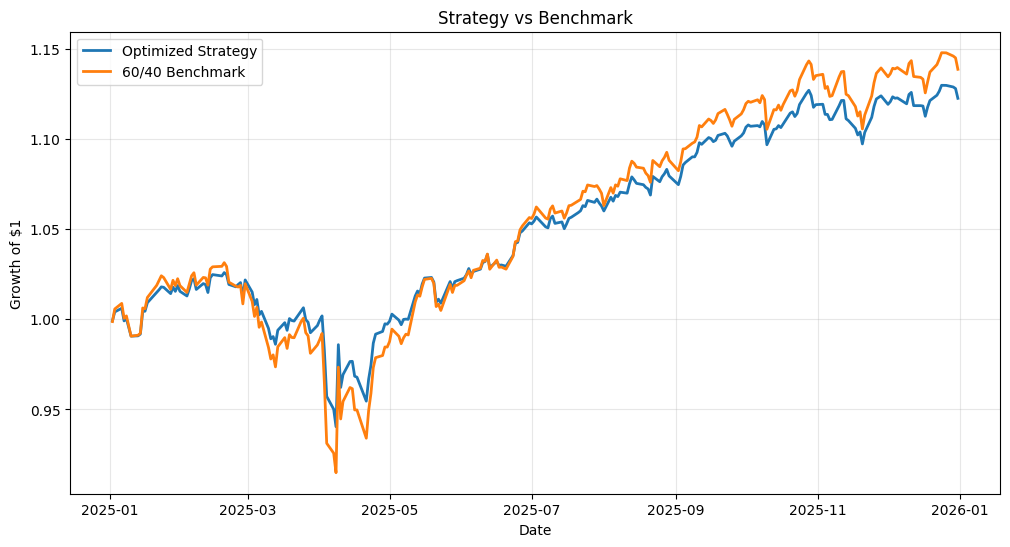

In [9]:
plt.figure(figsize=(12,6))

plt.plot(

strategy_cumulative,

label="Optimized Strategy",

linewidth=2

)

plt.plot(

benchmark_cumulative,

label="60/40 Benchmark",

linewidth=2

)

plt.title("Strategy vs Benchmark")

plt.xlabel("Date")

plt.ylabel("Growth of $1")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

Performance Metrics

In [10]:
def portfolio_metrics(daily_returns):

    total_return = (

        1 + daily_returns

    ).prod() - 1

    annual_return = (

        1 + total_return

    ) ** (

        252 / len(daily_returns)

    ) - 1

    sharpe = (

        daily_returns.mean()

        /

        daily_returns.std()

    ) * np.sqrt(252)

    cumulative = (

        1 + daily_returns

    ).cumprod()

    running_max = cumulative.cummax()

    drawdown = (

        cumulative - running_max

    ) / running_max

    max_drawdown = drawdown.min()

    return [

        total_return,

        annual_return,

        sharpe,

        max_drawdown

    ]

Compare Strategy and Benchmark

In [11]:
strategy_results = portfolio_metrics(
    strategy_daily
)

benchmark_results = portfolio_metrics(
    benchmark_daily
)

comparison = pd.DataFrame({

    "Metric":[

        "Total Return",

        "Annualized Return",

        "Sharpe Ratio",

        "Maximum Drawdown"

    ],

    "Strategy":strategy_results,

    "Benchmark":benchmark_results

})

comparison

,Metric,Strategy,Benchmark
0,Total Return,0.122434,0.138525
1,Annualized Return,0.123472,0.139707
2,Sharpe Ratio,1.300669,1.150871
3,Maximum Drawdown,-0.083278,-0.112888


Business Interpretation
Strategy Viability

The backtesting results compare the optimized portfolio against a traditional 60% SPY and 40% BND benchmark over the out-of-sample testing period. This evaluation provides an indication of whether incorporating machine learning forecasts and portfolio optimization can improve investment performance relative to a passive investment strategy.

If the optimized portfolio outperforms the benchmark in terms of total return and risk-adjusted return (Sharpe Ratio), it suggests that combining LSTM forecasting with Modern Portfolio Theory can add value to investment decision-making. However, if performance is similar or weaker, the results indicate that forecasting uncertainty and market volatility may limit the practical advantage of the model.

Limitations

This backtest assumes fixed portfolio weights throughout the evaluation period and does not account for transaction costs, taxes, market impact, or changes in investor preferences. Furthermore, future market conditions may differ from historical patterns, meaning that historical performance does not guarantee future investment results.